- Clase 01-06-26
- Luis Pablo López Iracheta

In [1]:
# Example of a simple perceptron
inputs = [2, 5, 3]
weights = [-1, 3,-2]
bias = 1

# Create a funtion to calculate the output of the perceptron
def perceptron(inputs, weights, bias):
    # Calculate the weighted sum of the inputs and weights
    weighted_sum = 0
    for i in range(len(inputs)):
        weighted_sum += inputs[i] * weights[i]
    
    # Add the bias to the weighted sum
    weighted_sum += bias
    
    # Apply the activation function (step function)
    if weighted_sum > 0:
        return weighted_sum, 1
    else:
        return weighted_sum, 0

# Calculate the output of the perceptron
result, output = perceptron(inputs, weights, bias)
print(f"Weighted sum: {result:.4f}, Output: {output}")

Weighted sum: 8.0000, Output: 1


In [3]:
import numpy as np

X = np.array([5.1, 3.5])
W = np.array([0.7, -0.2])
B = -0.5

def perceptron_tensor(X, W, B):
    # Calculate the weighted sum using numpy
    z = np.dot(X, W) + B
    
    # Apply the activation function (step function)
    output = 1 if z > 0 else 0
    
    return z, output
# Calculate the output of the perceptron
result, output = perceptron_tensor(X, W, B)
print(f"Weighted sum: {result:.4f}, Output: {output}")

Weighted sum: 2.3700, Output: 1


## Ejemplo con IRIS

In [6]:
# Example of a simple multi-layer perceptron
# Using the dataset from Iris, from sklearn.datasets import load_iris
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [9]:
# Load the Iris dataset
iris = load_iris()

# See the features and target
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df["Species"] = df["target"].map({0: "setosa", 1: "versicolor", 2: "virginica"})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [11]:
# Seleccionamos las columnas 2 y 3 (Ancho y Largo del pétalo) para el perceptrón
X = iris.data[:100, [2, 3]]  # Solo las primeras 100 filas (setosa y versicolor)
y = iris.target[:100]  # Solo las primeras 100 filas (setosa y versicolor)

# Convertimos las eqtiquetas setosas sera 1 y Versicolor sera 0
y = np.where(y == 0, 1, 0)

# Matriz de entradas
print(X.shape)
print(f"Clases en el dataset: {np.unique(y)}")



(100, 2)
Clases en el dataset: [0 1]


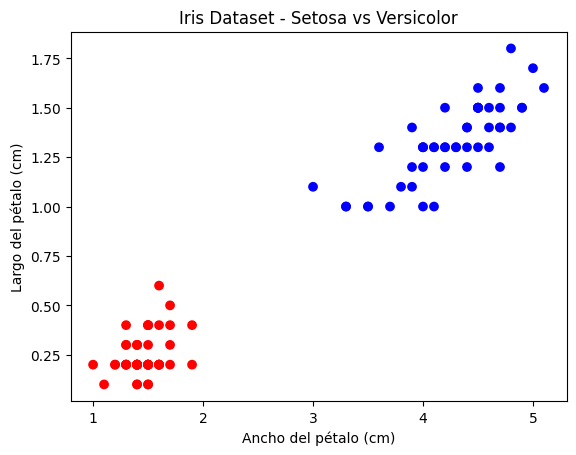

In [12]:
# Graficamos los datos
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.xlabel('Ancho del pétalo (cm)')
plt.ylabel('Largo del pétalo (cm)')
plt.title('Iris Dataset - Setosa vs Versicolor')
plt.show()

Predicciones para las nuevas muestras:
[1 1 1 1 1]
['Setosa' 'Setosa' 'Setosa' 'Setosa' 'Setosa']
Muestra 1: Ancho del pétalo = 1.2 cm, Largo del pétalo = 0.3 cm -> Predicción: Setosa
Muestra 2: Ancho del pétalo = 1.4 cm, Largo del pétalo = 0.5 cm -> Predicción: Setosa
Muestra 3: Ancho del pétalo = 1.6 cm, Largo del pétalo = 0.7 cm -> Predicción: Setosa
Muestra 4: Ancho del pétalo = 2.5 cm, Largo del pétalo = 1.0 cm -> Predicción: Setosa
Muestra 5: Ancho del pétalo = 3.2 cm, Largo del pétalo = 1.8 cm -> Predicción: Setosa


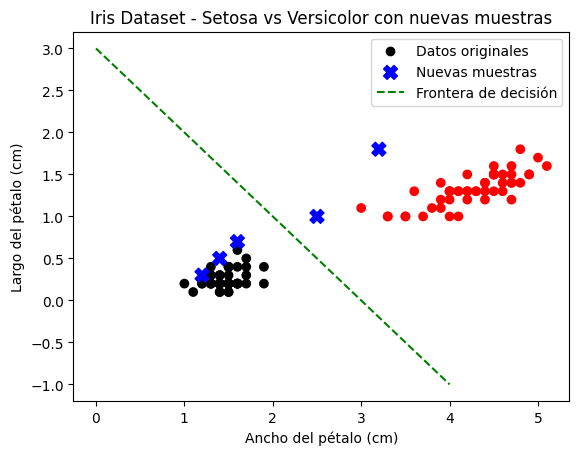

In [24]:
# X_nueva con flores pequeñas (Setosa) y flores grandes (Versicolor)
X_nueva = np.array([[1.2, 0.3],  # Muy pequeña, probablemente Setosa
                    [1.4, 0.5],  # Pequeña, probablemente Setosa
                    [1.6, 0.7],  # Mediana, podría ser Versicolor
                    [2.5, 1.0],  # Grande, probablemente Versicolor
                    [3.2, 1.8]]) # Muy grande, probablemente Versicolor



def activacion_escalon(z):
    return 1 if z > 0 else 0

z_nueva = np.dot(X_nueva, W) + B
y_nueva = np.array([activacion_escalon(z) for z in z_nueva])
print("Predicciones para las nuevas muestras:")
print(y_nueva)
predicciones_clases = np.where(y_nueva == 1, "Setosa", "Versicolor")
print(predicciones_clases)

# PResentación de resultados
nombres_clases = {1: "Setosa", 0: "Versicolor"}

for i in range(len(X_nueva)):
    print(f"Muestra {i+1}: Ancho del pétalo = {X_nueva[i, 0]:.1f} cm, Largo del pétalo = {X_nueva[i, 1]:.1f} cm -> Predicción: {nombres_clases[y_nueva[i]]}")

# Graficamos las nuevas muestras junto con las originales
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='flag', label='Datos originales')
plt.scatter(X_nueva[:, 0], X_nueva[:, 1], c=y_nueva, cmap='bwr', marker='X', s=100, label='Nuevas muestras')
plt.xlabel('Ancho del pétalo (cm)')
# Forntera de decisión z = -2 x1 - 2x2 + 6 
pl_x = np.linspace(0, 4, 100)
pl_y = (6 - 2 * pl_x) / 2
plt.plot(pl_x, pl_y, color='green', linestyle='--', label='Frontera de decisión')
plt.ylabel('Largo del pétalo (cm)')
plt.title('Iris Dataset - Setosa vs Versicolor con nuevas muestras')
plt.legend()
plt.show()

**Formula para actualizar los pesos**

Para cada unade las entrads de la neurona, su peso correspondiente se actualiza utilizando la siguiente ecuación:
$$ 
w_i = w_i + \Delta w_i
$$

Por otro lado, el sesgo se actualiza asi;
$$
b = b + n (\text{target} - \text{predicción})
$$

In [ ]:
class Perceptron:
    def __init__(self, eta=0.01, n_iter=10):
        self.eta = eta
        self.n_iter = n_iter

    def fit(self, X, y):
        self.w_ = np.zeros(X.shape[1])
        self.b = 0.0

        self.errors_ = []
        for epoch in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi # Actualizamos los pesos
                self.b += update        # Actualizamos el sesgo
                errors += int(update != 0.0) # Contamos los errores
            self.errors_.append(errors)


    def predict(self, X):
        z = np.dot(X, self.w_) + self.b
        if z > 0:
            return 1
        else:
            return 0
    

# Entrenamos el perceptrón con los datos de Iris
perceptron = Perceptron(eta=0.1, n_iter=10)
perceptron.fit(X, y)
# Predicciones para las nuevas muestras
y_nueva_perceptron = np.array([perceptron.predict(xi) for xi in X_nueva])
predicciones_clases_perceptron = np.where(y_nueva_perceptron == 1, "Setosa", "Versicolor")
print("Predicciones del perceptrón para las nuevas muestras:")
print(predicciones_clases_perceptron)

Predicciones del perceptrón para las nuevas muestras:
['Setosa' 'Setosa' 'Setosa' 'Versicolor' 'Versicolor']


In [ ]:
# Example of a simple multi-layer perceptron
